In [12]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
import os

In [6]:
from tcia_utils import nbia
import pandas as pd
import requests
import os

Using example data as in [TCIA_Notebooks](https://github.com/kirbyju/TCIA_Notebooks/blob/main/TCIA_Image_Visualization_with_itkWidgets.ipynb) 

In [7]:
cartName = "nbia-77761668716072016"

# retrieve cart metadata
cart_data = nbia.getSharedCart(cartName)

# download the series_uids list and return dataframe of metadata
df = nbia.downloadSeries(cart_data, format = "df")

# display dataframe
display(df)

2025-07-10 18:31:40,658:INFO:Success - Token saved to global api_call_headers variable and expires at 2025-07-10 20:31:40.658750
2025-07-10 18:31:40,659:INFO:Accessing public data anonymously. To access restricted data use nbia.getToken() with your credentials.
2025-07-10 18:31:40,659:INFO:Calling getContentsByName with parameters {'name': 'nbia-77761668716072016'}
2025-07-10 18:31:41,991:INFO:Downloading 2 out of 2 Series Instance UIDs (scans).
2025-07-10 18:31:41,991:INFO:Directory 'tciaDownload' already exists.
2025-07-10 18:31:41,992:WARNING:Series 1.3.6.1.4.1.14519.5.2.1.144673070302354240405004153445986965004 already downloaded and unzipped.
2025-07-10 18:31:43,119:WARNING:Series 1.3.6.1.4.1.14519.5.2.1.66734119033932110513438442707181367414 already downloaded and unzipped.
2025-07-10 18:31:44,246:INFO:Downloaded 0 out of 2 Series Instance UIDs (scans).
0 failed to download.
2 previously downloaded.


,Series UID,Collection,3rd Party Analysis,Data Description URI,Subject ID,Study UID,Study Description,Study Date,Series Description,Manufacturer,...,License Name,License URL,Annotation Size,Date Released,Annotations Flag,Manufacturer Model Name,Software Versions,TimeStamp,Series Date,Body Part Examined
0,1.3.6.1.4.1.14519.5.2.1.1446730703023542404050...,Pediatric-CT-SEG,NO,https://doi.org/10.7937/tcia.x0h0-1706,Pediatric-CT-SEG-00DCF4D6,1.3.6.1.4.1.14519.5.2.1.8859670961354389003042...,CT,10-09-2009,RTSTRUCT,Varian Medical Systems,...,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,0,Mon Nov 22 13:02:38 UTC 2021,false,ARIA RTM,4.2.7.0,Mon Nov 22 13:02:38 UTC 2021,NaN,NaN
1,1.3.6.1.4.1.14519.5.2.1.6673411903393211051343...,Pediatric-CT-SEG,NO,https://doi.org/10.7937/tcia.x0h0-1706,Pediatric-CT-SEG-00DCF4D6,1.3.6.1.4.1.14519.5.2.1.8859670961354389003042...,CT,10-09-2009,CT,GE MEDICAL SYSTEMS,...,Creative Commons Attribution 4.0 International...,https://creativecommons.org/licenses/by/4.0/,0,Mon Nov 22 14:20:32 UTC 2021,false,Revolution CT,revo_ct_21a.33,Mon Nov 22 14:20:32 UTC 2021,Fri Oct 09 00:00:00 UTC 2009,ABDOMEN


In [8]:
dicom_data_dir = "tciaDownload/"
ct_series_uid = df.at[df.Modality.eq('CT').idxmax(), 'Series UID']
dicom_ct_dir = os.path.join(dicom_data_dir, ct_series_uid)

In [13]:

def load_medical_image(image_path):
    """
    Load a medical image from various formats (DICOM, NIfTI, MetaImage).
    
    Args:
        image_path (str): Path to the medical image file or DICOM folder
        
    Returns:
        tuple: (image_data, spacing, origin, direction)
            - image_data: 3D numpy array of the image
            - spacing: Physical spacing between pixels (in mm)
            - origin: Physical location of first pixel
            - direction: Orientation matrix
    """
    # Determine if path is directory (DICOM) or file
    if os.path.isdir(image_path):
        # Read DICOM series
        reader = sitk.ImageSeriesReader()
        dicom_names = reader.GetGDCMSeriesFileNames(image_path)
        reader.SetFileNames(dicom_names)
        image = reader.Execute()
    else:
        # Read single file format (NIfTI, MetaImage)
        image = sitk.ReadImage(image_path)
    
    # Convert to numpy array (shape: depth, height, width)
    image_data = sitk.GetArrayFromImage(image)
    
    # Get metadata
    spacing = image.GetSpacing()
    origin = image.GetOrigin()
    direction = image.GetDirection()
    
    return image_data, spacing, origin, direction

In [14]:
def display_orthogonal_slices(image_data, slice_indices=None):
    """
    Display single slices from each orthogonal view.
    
    Args:
        image_data (numpy.ndarray): 3D image data (depth, height, width)
        slice_indices (tuple): Optional (axial, sagittal, coronal) slice indices
    """
    # Get image dimensions
    depth, height, width = image_data.shape
    
    # If no slice indices provided, use middle slices
    if slice_indices is None:
        d, h, w = (depth//2, height//2, width//2)
    
    # Create figure with three subplots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image_data[d, :, :], cmap='gray')
    axes[0].set_title(f'shape {w} x {h}')
    axes[1].imshow(image_data[:, h, :], cmap='gray')
    axes[1].set_title(f'shape {w} x {d}')
    axes[2].imshow(image_data[:, :, w], cmap='gray')
    axes[2].set_title(f'shape {h} x {d}')
    
    plt.tight_layout()
    plt.show()

In [16]:
image_data, spacing, origin, direction = load_medical_image(dicom_ct_dir)

In [17]:
print("Image shape (depth, height, width):", image_data.shape)
print("Pixel spacing (mm):", spacing)
print("Origin (mm):", origin)

Image shape (depth, height, width): (207, 512, 512)
Pixel spacing (mm): (0.585938, 0.585938, 2.0)
Origin (mm): (-139.39, -150.0, -429.4495)


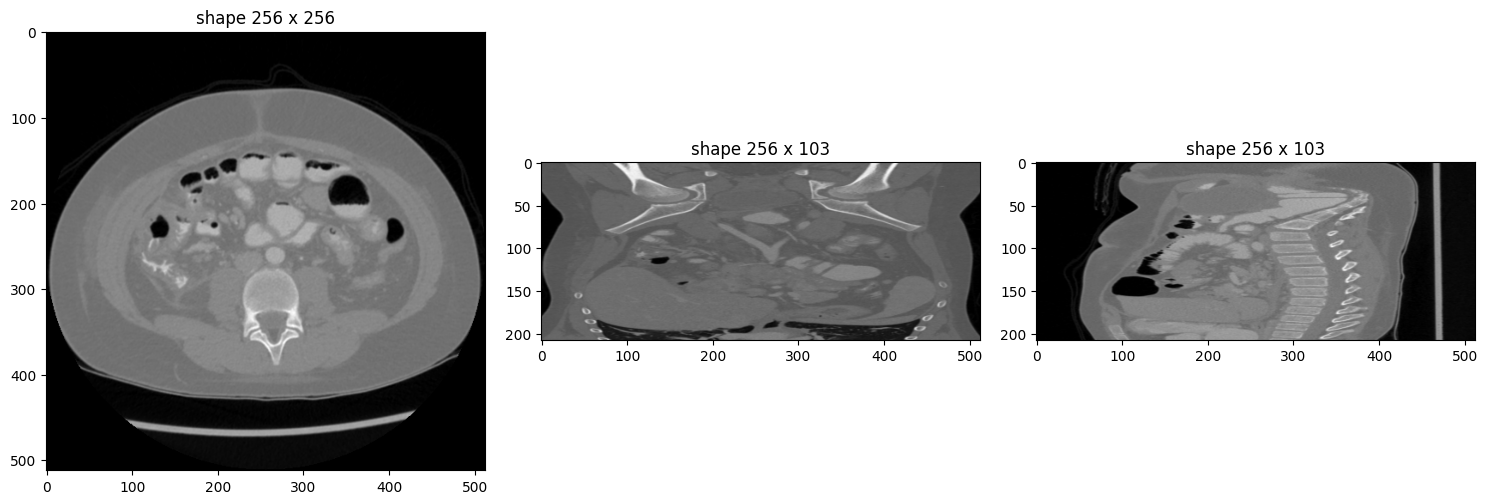

In [18]:
display_orthogonal_slices(image_data)

In [19]:
def display_orthogonal_slices_with_spacing(image_data, spacing):
    """
    Display single slices from each orthogonal view with proper aspect ratios.
    
    Args:
        image_data (numpy.ndarray): 3D image data (depth, height, width)
        spacing (tuple): Pixel spacing in mm (sx, sy, sz)
        slice_indices (tuple): Optional (axial, sagittal, coronal) slice indices
    """
    # Get image dimensions
    depth, height, width = image_data.shape # z, y, x
    
    d_z, h_y, w_x = (depth//2, height//2, width//2)
    
    # Create figure with three subplots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    sx, sy, sz = spacing # be careful, the order is reverse of the image_data order
    

    # image_data shape: (Y, X)
    aspect_0 = sy / sx 
    axes[0].imshow(image_data[d_z, :, :], cmap='gray', aspect=aspect_0)
    axes[0].set_title(f'shape {w_x} x {h_y}')
    
    # image_data shape: (Z, X)
    aspect_1 = sz / sx 
    axes[1].imshow(image_data[:, h_y, :], cmap='gray', aspect=aspect_1)
    axes[1].set_title(f'shape {w_x} x {d_z}')
    
    # image_data shape: (Z, Y)
    aspect_2 = sz / sy 
    axes[2].imshow(image_data[:, :, w_x], cmap='gray', aspect=aspect_2)
    axes[2].set_title(f'shape {h_y} x {d_z}')
    
    plt.tight_layout()
    plt.show()


Displaying slices with proper aspect ratios:


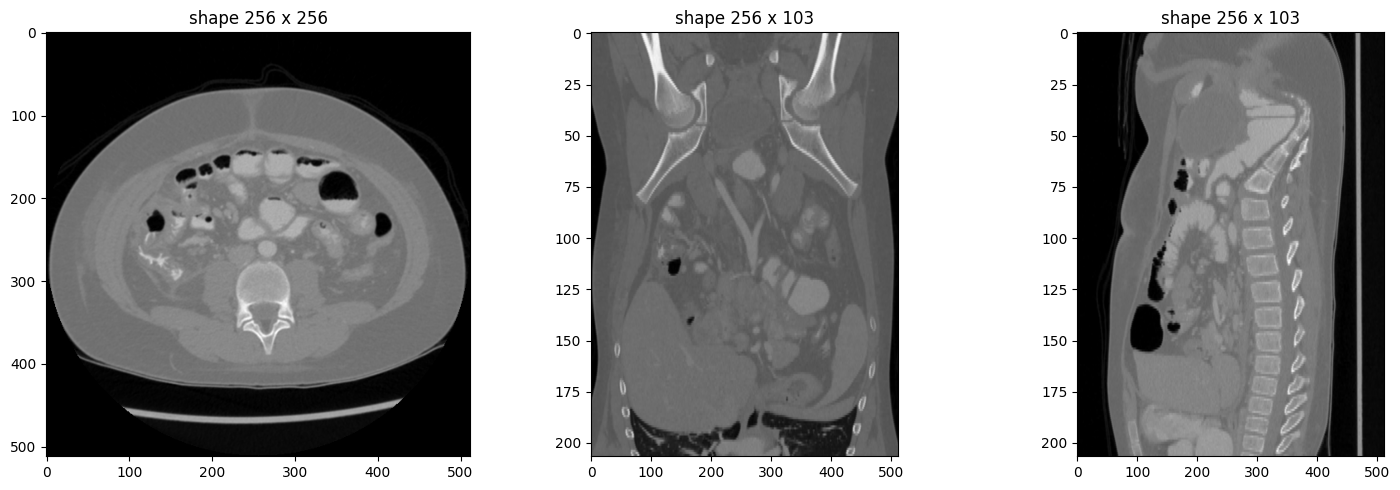

In [20]:
# Display orthogonal slices with proper aspect ratios
print("\nDisplaying slices with proper aspect ratios:")
display_orthogonal_slices_with_spacing(image_data, spacing)

In [21]:
from medical_viewer_matplot_mapback import ImageReader, AXIAL, CORONAL, SAGITTAL
def display_orthogonal_slices_with_views(image_reader:ImageReader):
    """
    Display single slices from each orthogonal view with proper orientation based on patient coordinate system.
    
    This function uses the ImageReader's view mapping to determine:
    Which axis of the image data corresponds to each anatomical view
    
    Args:
        image_reader (ImageReader): Configured image reader with loaded image data
        slice_indices (tuple): Optional (axial, sagittal, coronal) slice indices
    """
    # Get image dimensions
    depth, height, width = image_reader.image_numpy.shape
    
    # use middle slices to display

    d_z, h_y, w_x = (depth//2, height//2, width//2)
    
    # Get view mapping information
    view_indices = image_reader.view_indices

    # Create figure with three subplots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Get spacing for aspect ratios
    sx, sy, sz = image_reader.spacing
    
    # Display each view using the proper orientation
    for i, view in enumerate([AXIAL, SAGITTAL, CORONAL]):
        # Get the primary axis for this view
        dim_idx = view_indices[view]

            # Extract the raw 2D slice data based on view
        if dim_idx == 2:  # axial (slicing through Z-axis)
            img_data = image_reader.image_numpy[d_z, :, :] # shape: (Y, X)
            aspect = sy / sx  # sy / sx
        elif dim_idx == 1:  # coronal (slicing through Y-axis)
            img_data = image_reader.image_numpy[:, h_y, :] # shape: (Z, X)
            aspect = sz / sx   # sz / sx
        else:  # sagittal (slicing through X-axis)
            img_data = image_reader.image_numpy[:, :, w_x] # shape: (Z, Y)
            aspect = sz / sy   # sz / sy
    
        # Display the properly oriented slice
        axes[i].imshow(img_data, cmap='gray', aspect=aspect, origin='lower')
        axes[i].set_title(f'{view.capitalize()} View\nPrimary Axis: {dim_idx}')


Displaying slices with proper orientation:
Modality: CT


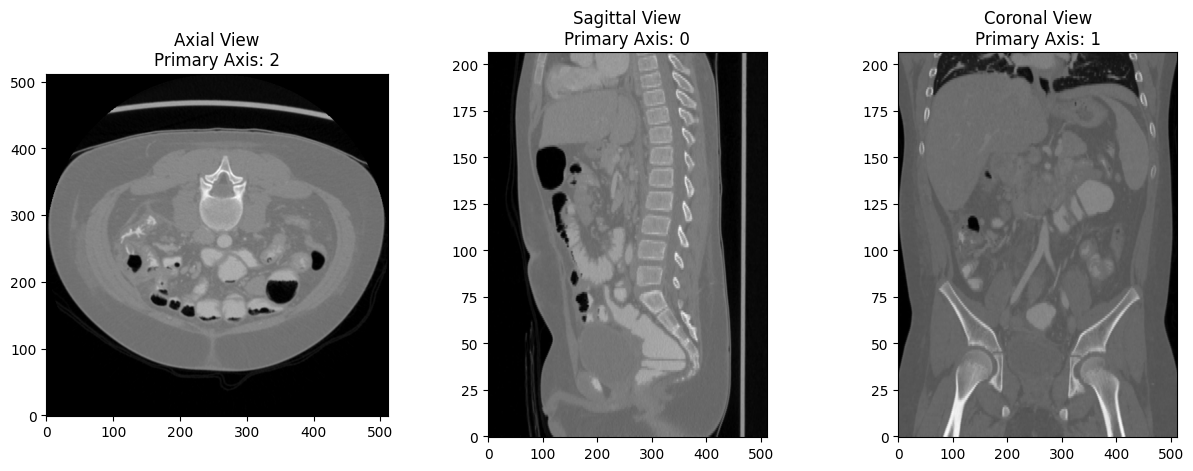

In [23]:
print("\nDisplaying slices with proper orientation:")
image_reader = ImageReader(dicom_ct_dir)  # or nifti_path or mha_path
display_orthogonal_slices_with_views(image_reader)

In [24]:
def demonstrate_view_mapping(image_reader: ImageReader):
    """
    Demonstrate how direction cosines are used to map image axes to anatomical views.
    
    This function shows:
    1. How the direction matrix is used to determine which axis corresponds to each view
    2. How dot products are used to measure alignment between axes
    3. How the primary axis for each view is determined
    
    Args:
        image_reader (ImageReader): Configured image reader with loaded image data
    """
    # Get the direction matrix and reshape to 3x3
    direction = np.array(image_reader.direction).reshape(3, 3)
    print("\nDirection Matrix (3x3):")
    print(direction)
    
    # Define standard anatomical directions
    X = np.array([1, 0, 0])  # Left-Right
    Y = np.array([0, 1, 0])  # Anterior-Posterior
    Z = np.array([0, 0, 1])  # Superior-Inferior
    
    # Define which direction corresponds to each view
    anatomical_directions = {
        'Axial': Z,     # Axial slices are perpendicular to Z-axis (up-down)
        'Coronal': Y,   # Coronal slices are perpendicular to Y-axis (front-back)
        'Sagittal': X   # Sagittal slices are perpendicular to X-axis (left-right)
    }
    
    print("\nView Mapping Analysis:")
    print("-" * 50)
    
    for view, anat_dir in anatomical_directions.items():
        print(f"\n{view} View:")
        print(f"Anatomical Direction: {anat_dir}")
        
        # Calculate dot products with each axis
        dot_products = [np.dot(direction[:, i], anat_dir) for i in range(3)]
        print(f"Dot products with image axes: {dot_products}")
        
        # Find best matching axis
        primary_axis = np.argmax([abs(dp) for dp in dot_products])
        print(f"Primary axis: {primary_axis}")
        print(f"Alignment strength: {abs(dot_products[primary_axis]):.3f}")

    
    print("\nSummary of View Mappings:")
    print("-" * 50)
    for view, anat_dir in anatomical_directions.items():
        dot_products = [np.dot(direction[:, i], anat_dir) for i in range(3)]
        primary_axis = np.argmax([abs(dp) for dp in dot_products])
        print(f"{view:8s}: Uses axis {primary_axis}")

In [25]:
# Demonstrate view mapping
print("\nDemonstrating view mapping:")
demonstrate_view_mapping(image_reader)


Demonstrating view mapping:

Direction Matrix (3x3):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

View Mapping Analysis:
--------------------------------------------------

Axial View:
Anatomical Direction: [0 0 1]
Dot products with image axes: [np.float64(0.0), np.float64(0.0), np.float64(1.0)]
Primary axis: 2
Alignment strength: 1.000

Coronal View:
Anatomical Direction: [0 1 0]
Dot products with image axes: [np.float64(0.0), np.float64(1.0), np.float64(0.0)]
Primary axis: 1
Alignment strength: 1.000

Sagittal View:
Anatomical Direction: [1 0 0]
Dot products with image axes: [np.float64(1.0), np.float64(0.0), np.float64(0.0)]
Primary axis: 0
Alignment strength: 1.000

Summary of View Mappings:
--------------------------------------------------
Axial   : Uses axis 2
Coronal : Uses axis 1
Sagittal: Uses axis 0


In [26]:
def display_orthogonal_slices_with_orientation(image_reader:ImageReader):
    """
    Display single slices from each orthogonal view with proper orientation based on patient coordinate system.
    
    This function uses the ImageReader's view mapping to determine:
    1. Which axis of the image data corresponds to each anatomical view
    2. How to properly orient each slice to match medical conventions
    
    Args:
        image_reader (ImageReader): Configured image reader with loaded image data
        slice_indices (tuple): Optional (axial, sagittal, coronal) slice indices
    """
    # Get image dimensions
    depth, height, width = image_reader.image_numpy.shape
    
    # use middle slices to display

    d_z, h_y, w_x = (depth//2, height//2, width//2)
    
    # Get view mapping information
    view_indices = image_reader.view_indices
    view_transforms = image_reader.view_transforms

    # Create figure with three subplots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Get spacing for aspect ratios
    sx, sy, sz = image_reader.spacing
    
    # Display each view using the proper orientation
    for i, view in enumerate([AXIAL, SAGITTAL, CORONAL]):
        # Get the primary axis for this view
        dim_idx = view_indices[view]

            # Extract the raw 2D slice data based on view
        if dim_idx == 2:  # axial (slicing through Z-axis)
            img_data = image_reader.image_numpy[d_z, :, :] # shape: (Y, X)
            aspect = sy / sx  # sy / sx
        elif dim_idx == 1:  # coronal (slicing through Y-axis)
            img_data = image_reader.image_numpy[:, h_y, :] # shape: (Z, X)
            aspect = sz / sx   # sz / sx
        else:  # sagittal (slicing through X-axis)
            img_data = image_reader.image_numpy[:, :, w_x] # shape: (Z, Y)
            aspect = sz / sy   
        
        transform = view_transforms[view]
        print(f"View:{view}, transform: {transform}")
        
        # Apply orientation transformations
        if transform['transpose']:
            img_data = np.transpose(img_data)
            aspect = 1.0 / aspect
        
        if transform['flip_x']:
            img_data = np.flip(img_data, axis=1)
        if transform['flip_y']:
            img_data = np.flip(img_data, axis=0)
        
        # Display the properly oriented slice
        axes[i].imshow(img_data, cmap='gray', aspect=aspect, origin='lower')
        axes[i].set_title(f'{view.capitalize()} View\nPrimary Axis: {dim_idx}')
    
    plt.tight_layout()
    plt.show()

View:axial, transform: {'transpose': False, 'flip_x': np.False_, 'flip_y': np.True_, 'x_axis': 0, 'y_axis': 1}
View:sagittal, transform: {'transpose': False, 'flip_x': np.False_, 'flip_y': np.False_, 'x_axis': 1, 'y_axis': 2}
View:coronal, transform: {'transpose': False, 'flip_x': np.False_, 'flip_y': np.False_, 'x_axis': 0, 'y_axis': 2}


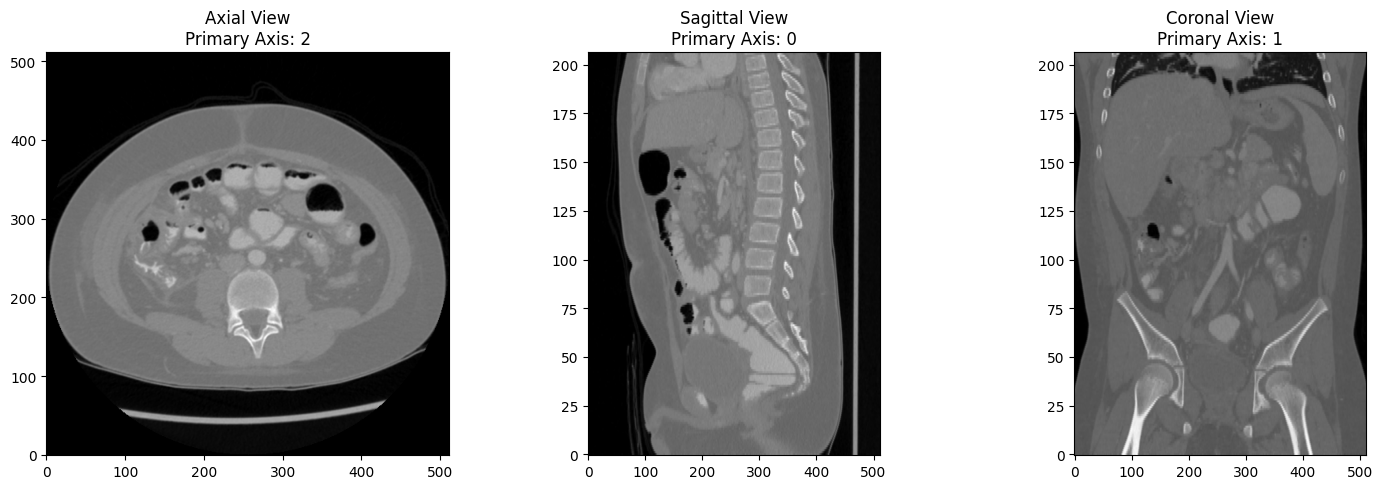

In [27]:
display_orthogonal_slices_with_orientation(image_reader)

In [33]:
# avoid printing all logs which show paths, comment out to see warnings.
import warnings
warnings.filterwarnings("ignore") 

In [30]:
from medical_viewer_matplot import MedicalImageReader, MedicalViewerMatplot
import os
%matplotlib widget

In [31]:
modality = "CT"
image_reader = MedicalImageReader(image_path=dicom_ct_dir, modality=modality)
medical_viewer = MedicalViewerMatplot(image_reader)

Modality: CT
Image tciaDownload/1.3.6.1.4.1.14519.5.2.1.66734119033932110513438442707181367414 read


=== IMAGE INFORMATION ===
Array shape (depth, height, width): (207, 512, 512)
Pixel spacing (x, y, z): (0.585938, 0.585938, 2.0)
View indices (which axis for each view): {'axial': np.int64(2), 'coronal': np.int64(1), 'sagittal': np.int64(0)}
View transforms (orientation corrections): {'axial': {'transpose': False, 'flip_x': np.False_, 'flip_y': np.True_, 'x_axis': 0, 'y_axis': 1}, 'coronal': {'transpose': False, 'flip_x': np.False_, 'flip_y': np.False_, 'x_axis': 0, 'y_axis': 2}, 'sagittal': {'transpose': False, 'flip_x': np.False_, 'flip_y': np.False_, 'x_axis': 1, 'y_axis': 2}}
axial view: using dimension 2, max slices: 206, starting at slice: 103
sagittal view: using dimension 0, max slices: 511, starting at slice: 255
coronal view: using dimension 1, max slices: 511, starting at slice: 255
Setting initial crosshairs at center: (256, 256, 103)


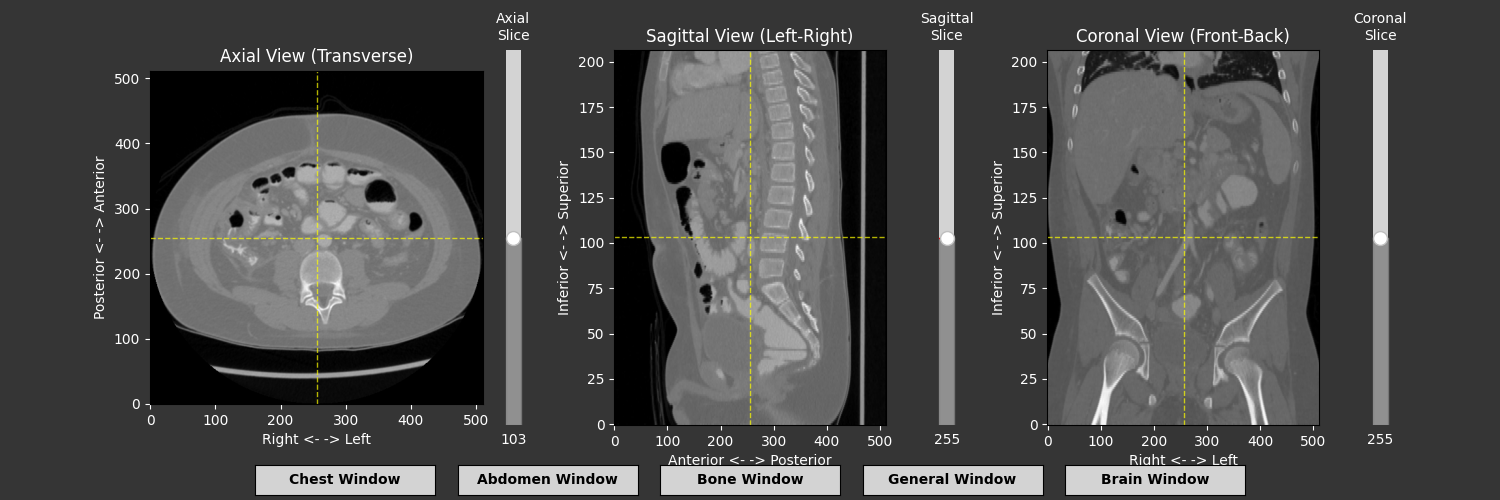

In [34]:
# Start the interactive viewer
medical_viewer.view_dicom_series()